## Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

sns.set_style("whitegrid")

In [4]:
import plotly.express as px
from textblob import TextBlob

## Load Dataset

In [5]:
df=pd.read_csv("googleplaystore.csv")

## Basic Inspection for understanding dataset

In [6]:
df.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


In [7]:
df.tail()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
10836,Sya9a Maroc - FR,FAMILY,4.5,38,53M,"5,000+",Free,0,Everyone,Education,"July 25, 2017",1.48,4.1 and up
10837,Fr. Mike Schmitz Audio Teachings,FAMILY,5.0,4,3.6M,100+,Free,0,Everyone,Education,"July 6, 2018",1.0,4.1 and up
10838,Parkinson Exercices FR,MEDICAL,NaN,3,9.5M,"1,000+",Free,0,Everyone,Medical,"January 20, 2017",1.0,2.2 and up
10839,The SCP Foundation DB fr nn5n,BOOKS_AND_REFERENCE,4.5,114,Varies with device,"1,000+",Free,0,Mature 17+,Books & Reference,"January 19, 2015",Varies with device,Varies with device
10840,iHoroscope - 2018 Daily Horoscope & Astrology,LIFESTYLE,4.5,398307,19M,"10,000,000+",Free,0,Everyone,Lifestyle,"July 25, 2018",Varies with device,Varies with device


In [9]:
df.shape

(10841, 13)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10841 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10841 non-null  object 
 1   Category        10841 non-null  object 
 2   Rating          9367 non-null   float64
 3   Reviews         10841 non-null  object 
 4   Size            10841 non-null  object 
 5   Installs        10841 non-null  object 
 6   Type            10840 non-null  object 
 7   Price           10841 non-null  object 
 8   Content Rating  10840 non-null  object 
 9   Genres          10841 non-null  object 
 10  Last Updated    10841 non-null  object 
 11  Current Ver     10833 non-null  object 
 12  Android Ver     10838 non-null  object 
dtypes: float64(1), object(12)
memory usage: 1.1+ MB


In [12]:
df.columns

Index(['App', 'Category', 'Rating', 'Reviews', 'Size', 'Installs', 'Type',
       'Price', 'Content Rating', 'Genres', 'Last Updated', 'Current Ver',
       'Android Ver'],
      dtype='object')

In [13]:
df.describe()

,Rating
count,9367.000000
mean,4.193338
std,0.537431
min,1.000000
25%,4.000000
50%,4.300000
75%,4.500000
max,19.000000


In [14]:
df.isnull().mean()*100

App                0.000000
Category           0.000000
Rating            13.596532
Reviews            0.000000
Size               0.000000
Installs           0.000000
Type               0.009224
Price              0.000000
Content Rating     0.009224
Genres             0.000000
Last Updated       0.000000
Current Ver        0.073794
Android Ver        0.027673
dtype: float64

In [15]:
df.duplicated().sum()

np.int64(483)

In [16]:
df=df.drop_duplicates()

In [17]:
df.duplicated().sum()

np.int64(0)

## Fix the corrupted 1.9 category row

In [18]:
 df = df[df["Category"] != "1.9"]

In [19]:
df['Category'].unique()

array(['ART_AND_DESIGN', 'AUTO_AND_VEHICLES', 'BEAUTY',
       'BOOKS_AND_REFERENCE', 'BUSINESS', 'COMICS', 'COMMUNICATION',
       'DATING', 'EDUCATION', 'ENTERTAINMENT', 'EVENTS', 'FINANCE',
       'FOOD_AND_DRINK', 'HEALTH_AND_FITNESS', 'HOUSE_AND_HOME',
       'LIBRARIES_AND_DEMO', 'LIFESTYLE', 'GAME', 'FAMILY', 'MEDICAL',
       'SOCIAL', 'SHOPPING', 'PHOTOGRAPHY', 'SPORTS', 'TRAVEL_AND_LOCAL',
       'TOOLS', 'PERSONALIZATION', 'PRODUCTIVITY', 'PARENTING', 'WEATHER',
       'VIDEO_PLAYERS', 'NEWS_AND_MAGAZINES', 'MAPS_AND_NAVIGATION'],
      dtype=object)

## Clean the Reviews column

In [20]:
df["Reviews"] = df["Reviews"].astype(str).str.replace("M", "e6", regex=False)
df["Reviews"] = pd.to_numeric(df["Reviews"], errors="coerce")

In [21]:
df["Reviews"].dtype

dtype('int64')

## Clean the Installs column

In [22]:
df["Installs"] = (
    df["Installs"]
    .astype(str)
    .str.replace(",", "", regex=False)
    .str.replace("+", "", regex=False)
)

In [23]:
df["Installs"] = pd.to_numeric(df["Installs"], errors="coerce")

In [24]:
df["Installs"].head()

0       10000
1      500000
2     5000000
3    50000000
4      100000
Name: Installs, dtype: int64

## Clean size

In [25]:
def convert_size(size):
    if pd.isna(size):
        return np.nan

    size = str(size)

    if size == "Varies with device":
        return np.nan

    if size.endswith("M"):
        return float(size.replace("M", ""))

    if size.endswith("k"):
        return float(size.replace("k", "")) / 1024

    return np.nan

In [26]:
df["Size_MB"] = df["Size"].apply(convert_size)

In [27]:
df[["Size", "Size_MB"]].head(10)

,Size,Size_MB
0,19M,19.0
1,14M,14.0
2,8.7M,8.7
3,25M,25.0
4,2.8M,2.8
5,5.6M,5.6
6,19M,19.0
7,29M,29.0
8,33M,33.0
9,3.1M,3.1


## Clean Price

In [28]:
df["Price"] = df["Price"].astype(str).str.replace("$", "", regex=False)

In [29]:
df["Price"] = pd.to_numeric(df["Price"], errors="coerce")

## Handle missing ratings

In [30]:
df['Rating'].isnull().sum()

np.int64(1465)

## Final cleaning check

In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10357 entries, 0 to 10840
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10357 non-null  object 
 1   Category        10357 non-null  object 
 2   Rating          8892 non-null   float64
 3   Reviews         10357 non-null  int64  
 4   Size            10357 non-null  object 
 5   Installs        10357 non-null  int64  
 6   Type            10356 non-null  object 
 7   Price           10357 non-null  float64
 8   Content Rating  10357 non-null  object 
 9   Genres          10357 non-null  object 
 10  Last Updated    10357 non-null  object 
 11  Current Ver     10349 non-null  object 
 12  Android Ver     10355 non-null  object 
 13  Size_MB         8831 non-null   float64
dtypes: float64(3), int64(2), object(9)
memory usage: 1.2+ MB


In [32]:
df.isnull().sum()

App                  0
Category             0
Rating            1465
Reviews              0
Size                 0
Installs             0
Type                 1
Price                0
Content Rating       0
Genres               0
Last Updated         0
Current Ver          8
Android Ver          2
Size_MB           1526
dtype: int64

In [33]:
df.describe()

,Rating,Reviews,Installs,Price,Size_MB
count,8892.000000,1.035700e+04,1.035700e+04,10357.000000,8831.000000
mean,4.187877,4.059046e+05,1.415776e+07,1.030800,21.287413
std,0.522377,2.696778e+06,8.023955e+07,16.278625,22.540591
min,1.000000,0.000000e+00,0.000000e+00,0.000000,0.008301
25%,4.000000,3.200000e+01,1.000000e+03,0.000000,4.700000
50%,4.300000,1.680000e+03,1.000000e+05,0.000000,13.000000
75%,4.500000,4.641600e+04,1.000000e+06,0.000000,29.000000
max,5.000000,7.815831e+07,1.000000e+09,400.000000,100.000000


## Category Analysis

In [34]:
category_counts = df["Category"].value_counts()
category_counts

Category
FAMILY                 1943
GAME                   1121
TOOLS                   843
BUSINESS                427
MEDICAL                 408
PRODUCTIVITY            407
PERSONALIZATION         388
LIFESTYLE               373
COMMUNICATION           366
FINANCE                 360
SPORTS                  351
PHOTOGRAPHY             322
HEALTH_AND_FITNESS      306
SOCIAL                  280
NEWS_AND_MAGAZINES      264
TRAVEL_AND_LOCAL        237
BOOKS_AND_REFERENCE     230
SHOPPING                224
DATING                  196
VIDEO_PLAYERS           175
MAPS_AND_NAVIGATION     137
EDUCATION               130
FOOD_AND_DRINK          124
ENTERTAINMENT           111
AUTO_AND_VEHICLES        85
LIBRARIES_AND_DEMO       85
WEATHER                  82
HOUSE_AND_HOME           80
ART_AND_DESIGN           65
EVENTS                   64
PARENTING                60
COMICS                   60
BEAUTY                   53
Name: count, dtype: int64

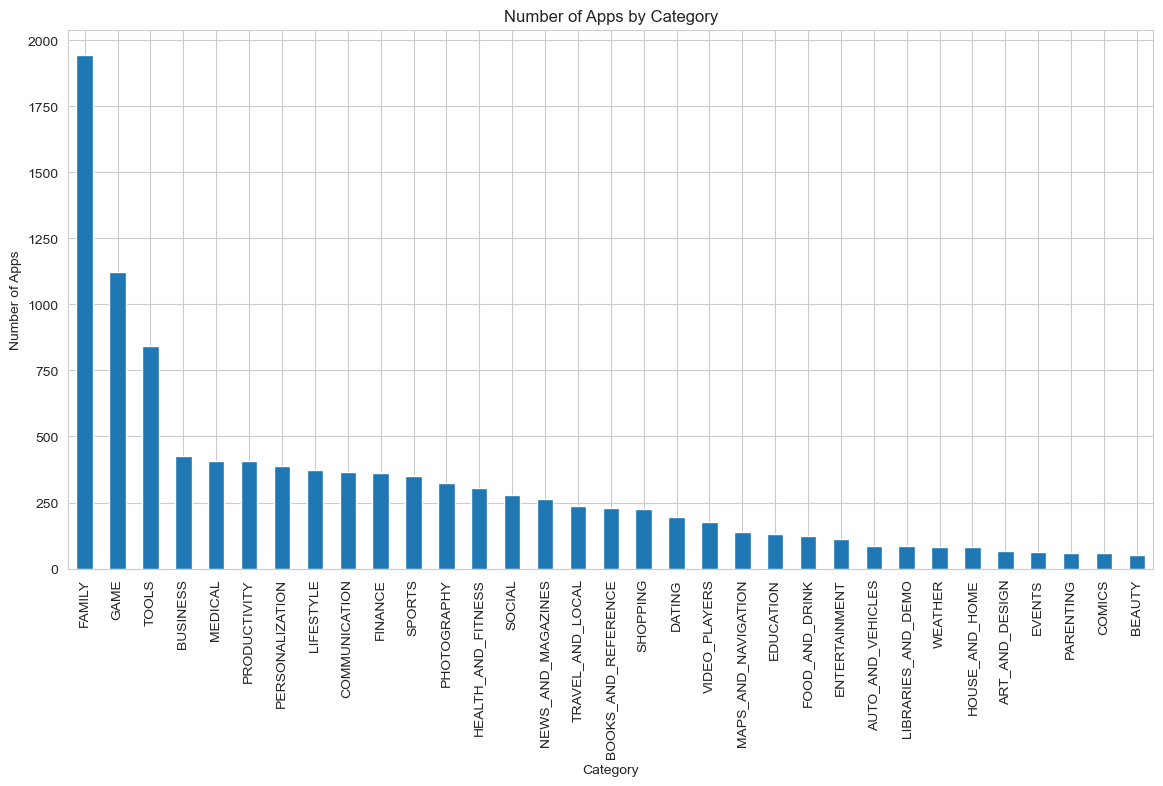

In [35]:
plt.figure(figsize=(14,7))

category_counts.plot(kind="bar")

plt.title("Number of Apps by Category")
plt.xlabel("Category")
plt.ylabel("Number of Apps")
plt.xticks(rotation=90)

plt.show()

**insight:-**
* The category has high app concentration, suggesting stronger competition and potentially higher difficulty for new entrants.

## Rating Analysis

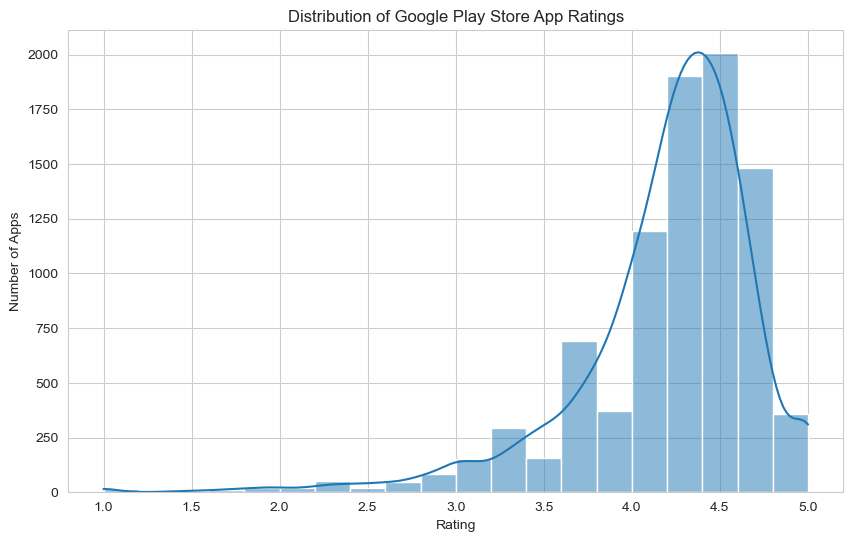

In [36]:
plt.figure(figsize=(10,6))

sns.histplot(df["Rating"].dropna(), bins=20, kde=True)

plt.title("Distribution of Google Play Store App Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Apps")

plt.show()

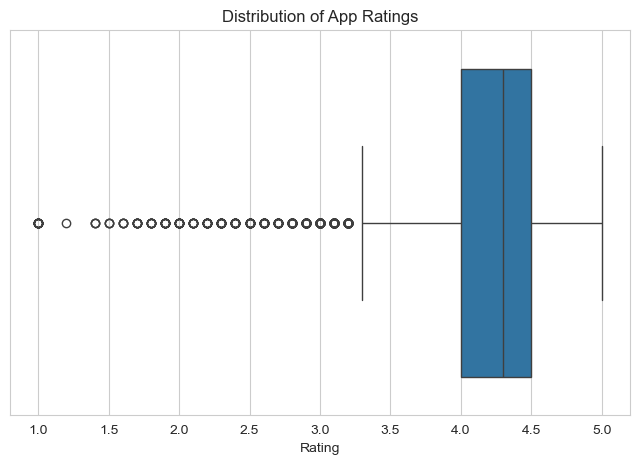

In [37]:
plt.figure(figsize=(8,5))

sns.boxplot(x=df["Rating"])

plt.title("Distribution of App Ratings")
plt.xlabel("Rating")

plt.show()

## Average rating by category

In [38]:
category_rating = (
    df.groupby("Category")["Rating"]
    .mean()
    .sort_values(ascending=False)
)

In [39]:
category_rating

Category
EVENTS                 4.435556
EDUCATION              4.375969
ART_AND_DESIGN         4.358065
BOOKS_AND_REFERENCE    4.347458
PERSONALIZATION        4.333871
PARENTING              4.300000
GAME                   4.281285
BEAUTY                 4.278571
HEALTH_AND_FITNESS     4.261450
SOCIAL                 4.254918
SHOPPING               4.251485
WEATHER                4.244000
SPORTS                 4.225175
PRODUCTIVITY           4.201796
FAMILY                 4.191153
AUTO_AND_VEHICLES      4.190411
PHOTOGRAPHY            4.182895
MEDICAL                4.182450
LIBRARIES_AND_DEMO     4.178462
HOUSE_AND_HOME         4.164706
FOOD_AND_DRINK         4.164151
COMICS                 4.155172
COMMUNICATION          4.151466
ENTERTAINMENT          4.136036
NEWS_AND_MAGAZINES     4.128505
FINANCE                4.127445
BUSINESS               4.102593
LIFESTYLE              4.096066
TRAVEL_AND_LOCAL       4.094146
VIDEO_PLAYERS          4.063750
MAPS_AND_NAVIGATION    4.051613

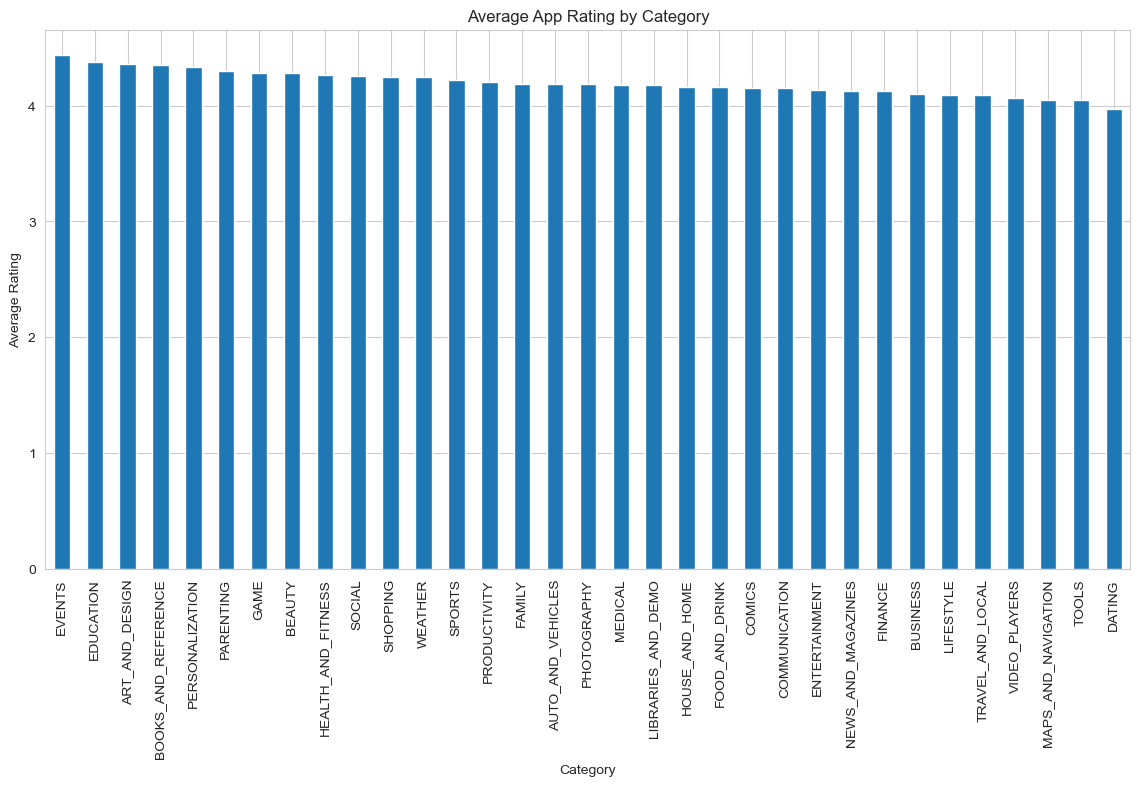

In [40]:
plt.figure(figsize=(14,7))

category_rating.plot(kind="bar")

plt.title("Average App Rating by Category")
plt.xlabel("Category")
plt.ylabel("Average Rating")
plt.xticks(rotation=90)

plt.show()

In [41]:
category_summary = df.groupby("Category").agg(
    App_Count=("App", "count"),
    Average_Rating=("Rating", "mean")
)

category_summary.sort_values(
    "Average_Rating",
    ascending=False
).head(10)

,App_Count,Average_Rating
Category,,
EVENTS,64,4.435556
EDUCATION,130,4.375969
ART_AND_DESIGN,65,4.358065
BOOKS_AND_REFERENCE,230,4.347458
PERSONALIZATION,388,4.333871
PARENTING,60,4.300000
GAME,1121,4.281285
BEAUTY,53,4.278571
HEALTH_AND_FITNESS,306,4.261450


## Size vs Installs Analysis

In [42]:
size_install_df = df.dropna(subset=["Size_MB", "Installs"])

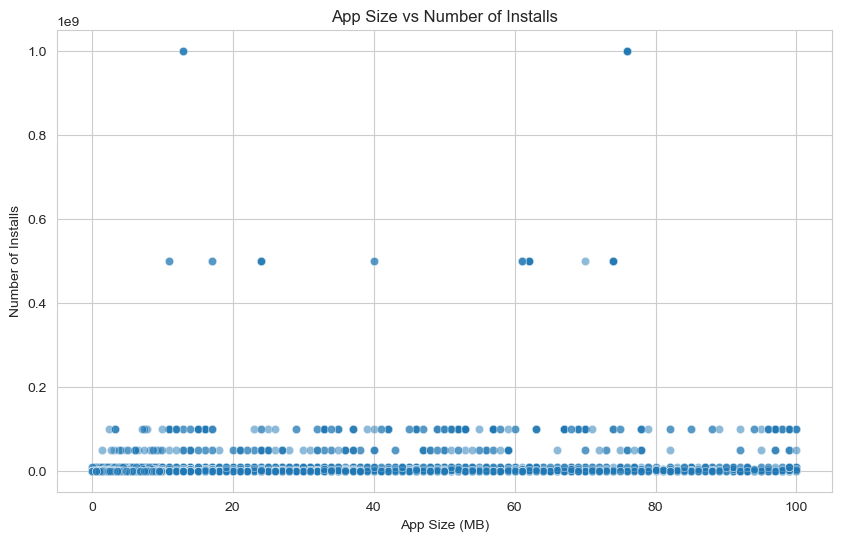

In [43]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=size_install_df,
    x="Size_MB",
    y="Installs",
    alpha=0.5
)

plt.title("App Size vs Number of Installs")
plt.xlabel("App Size (MB)")
plt.ylabel("Number of Installs")

plt.show()

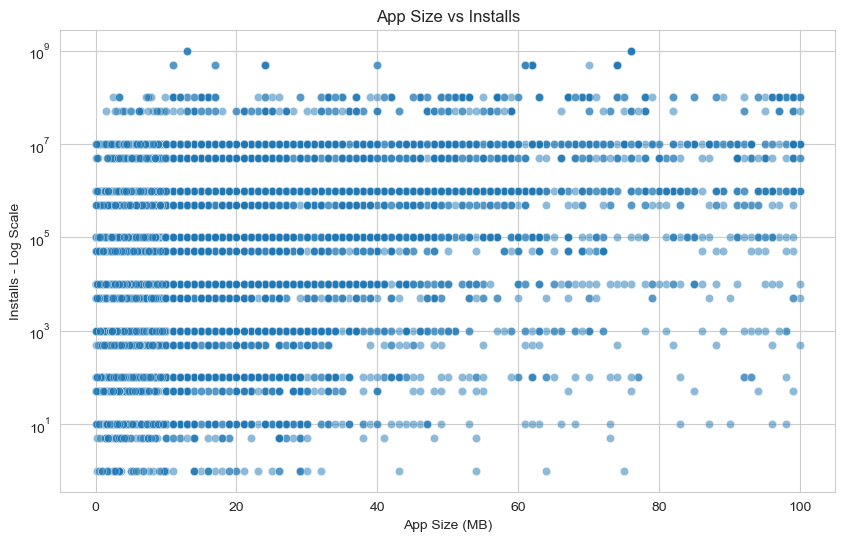

In [44]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=size_install_df,
    x="Size_MB",
    y="Installs",
    alpha=0.5
)

plt.yscale("log")

plt.title("App Size vs Installs")
plt.xlabel("App Size (MB)")
plt.ylabel("Installs - Log Scale")

plt.show()

In [45]:
correlation = size_install_df["Size_MB"].corr(
    size_install_df["Installs"]
)

print("Correlation:", correlation)

Correlation: 0.16887201973119761


## Free vs Paid Apps

In [46]:
df["Type"].value_counts()

Type
Free    9591
Paid     765
Name: count, dtype: int64

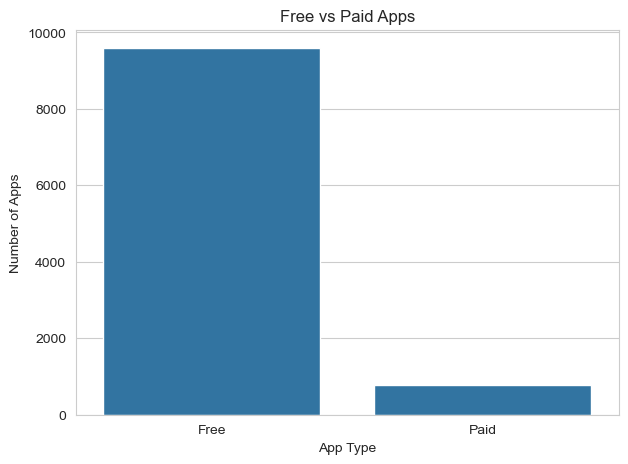

In [47]:
plt.figure(figsize=(7,5))

sns.countplot(data=df, x="Type")

plt.title("Free vs Paid Apps")
plt.xlabel("App Type")
plt.ylabel("Number of Apps")

plt.show()

In [48]:
type_percentage = df["Type"].value_counts(normalize=True) * 100
type_percentage

Type
Free    92.612978
Paid     7.387022
Name: proportion, dtype: float64

## Price Distribution of paid Apps

In [49]:
paid_apps = df[df["Type"] == "Paid"].copy()

In [50]:
paid_apps["Price"].describe()

count    765.000000
mean      13.955556
std       58.406966
min        0.990000
25%        1.490000
50%        2.990000
75%        4.990000
max      400.000000
Name: Price, dtype: float64

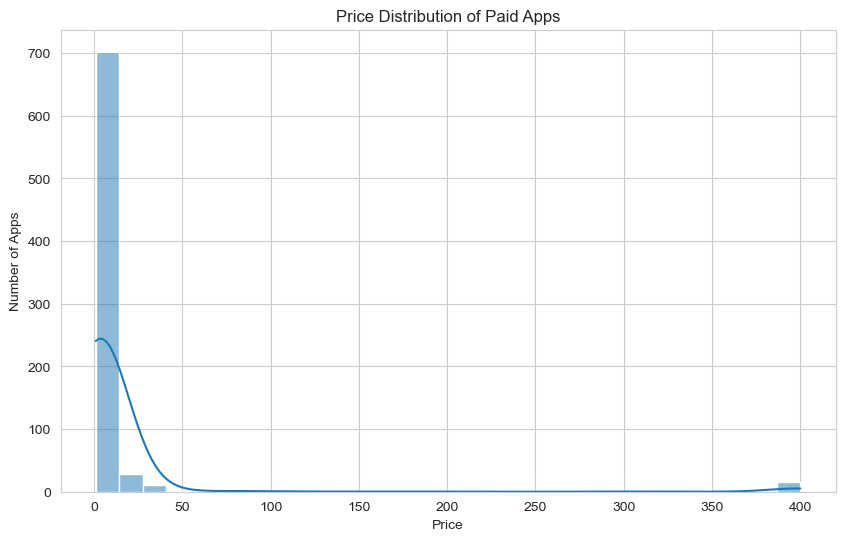

In [51]:
plt.figure(figsize=(10,6))

sns.histplot(
    paid_apps["Price"],
    bins=30,
    kde=True
)

plt.title("Price Distribution of Paid Apps")
plt.xlabel("Price")
plt.ylabel("Number of Apps")

plt.show()

In [52]:
paid_apps.sort_values(
    "Price",
    ascending=False
)[["App", "Category", "Price"]].head(10)

,App,Category,Price
4367,I'm Rich - Trump Edition,LIFESTYLE,400.00
5362,I Am Rich Pro,FAMILY,399.99
5358,I am Rich!,FINANCE,399.99
4362,💎 I'm rich,LIFESTYLE,399.99
5364,I am rich (Most expensive app),FINANCE,399.99
5354,I am Rich Plus,FAMILY,399.99
9934,I'm Rich/Eu sou Rico/أنا غني/我很有錢,LIFESTYLE,399.99
5356,I Am Rich Premium,FINANCE,399.99
4197,most expensive app (H),FAMILY,399.99
5351,I am rich,LIFESTYLE,399.99


## Estimated Revenue

In [53]:
df["Estimated_Revenue"] = df["Price"] * df["Installs"]

In [54]:
revenue_by_category = (
    df.groupby("Category")["Estimated_Revenue"]
    .sum()
    .sort_values(ascending=False)
)

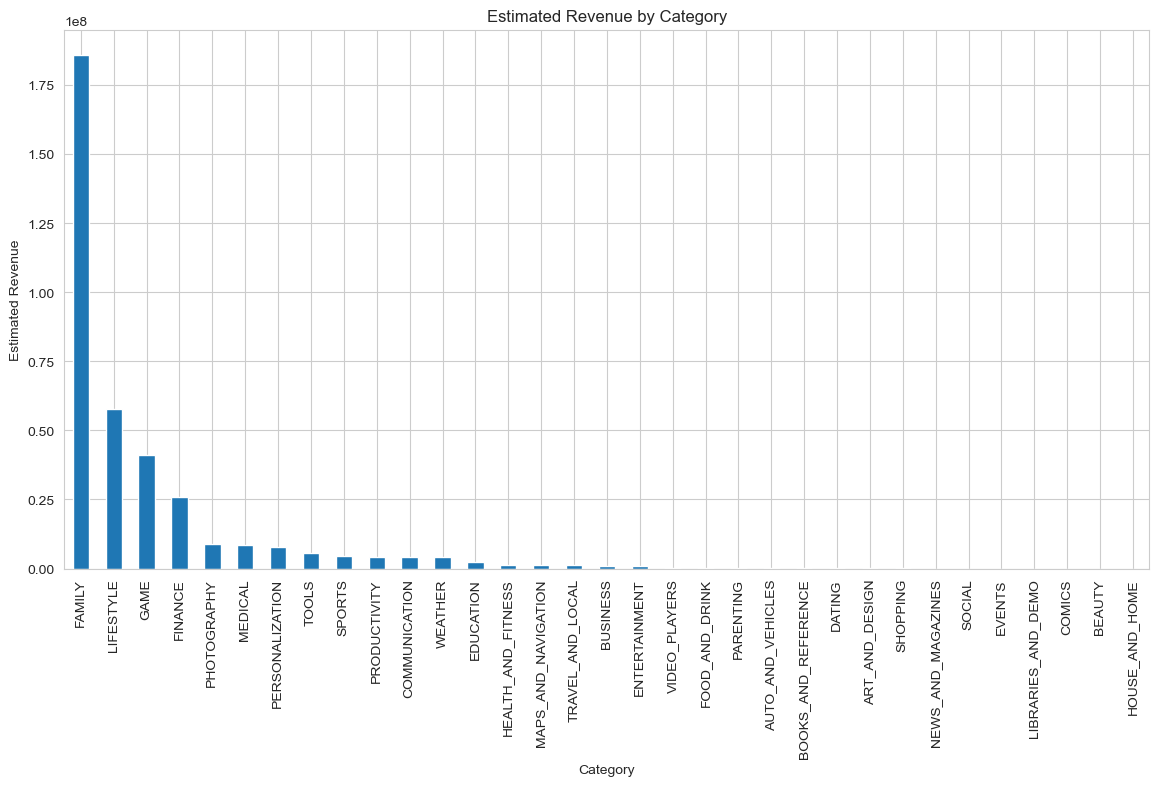

In [55]:
plt.figure(figsize=(14,7))

revenue_by_category.plot(kind="bar")

plt.title("Estimated Revenue by Category")
plt.xlabel("Category")
plt.ylabel("Estimated Revenue")

plt.xticks(rotation=90)

plt.show()

Observation:
* Estimated revenue is calculated as Price × Installs and should be interpreted as a directional estimate rather than actual developer revenue.

## Interactive Plotly Visualization

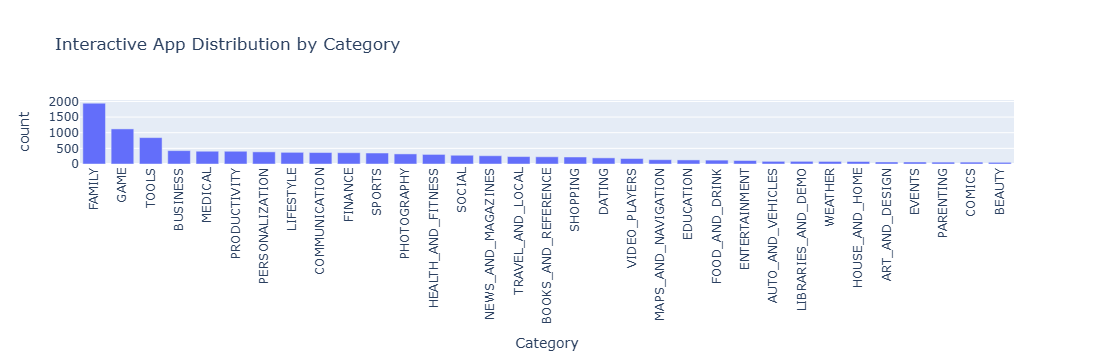

In [56]:
fig = px.bar(
    category_counts.reset_index(),
    x="Category",
    y="count",
    title="Interactive App Distribution by Category"
)

fig.update_layout(
    xaxis_tickangle=-90
)

fig.show()

## User Reviews Sentiment Analysis

In [57]:
reviews = pd.read_csv("googleplaystore_user_reviews.csv")

In [58]:
reviews.head()

,App,Translated_Review,Sentiment,Sentiment_Polarity,Sentiment_Subjectivity
0,10 Best Foods for You,I like eat delicious food. That's I'm cooking ...,Positive,1.00,0.533333
1,10 Best Foods for You,This help eating healthy exercise regular basis,Positive,0.25,0.288462
2,10 Best Foods for You,NaN,NaN,NaN,NaN
3,10 Best Foods for You,Works great especially going grocery store,Positive,0.40,0.875000
4,10 Best Foods for You,Best idea us,Positive,1.00,0.300000


## Sentiment Classification

In [59]:
reviews['Sentiment'].value_counts()

Sentiment
Positive    23998
Negative     8271
Neutral      5163
Name: count, dtype: int64

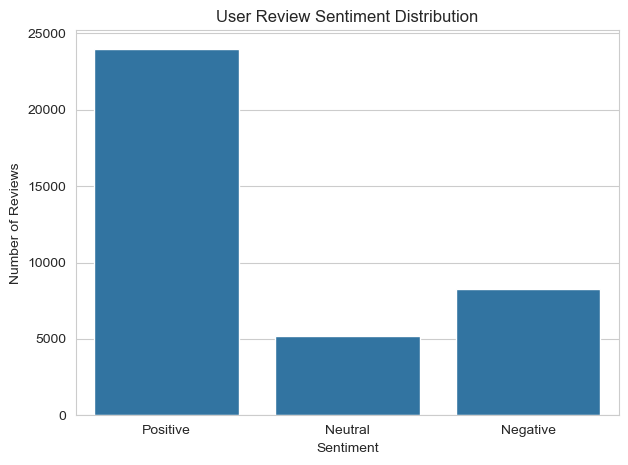

In [60]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=reviews,
    x="Sentiment"
)

plt.title("User Review Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")

plt.show()

## TextBlob Sentiment Analysis

In [61]:
from textblob import TextBlob

In [62]:
def get_polarity(text):
    if pd.isna(text):
        return np.nan
    return TextBlob(str(text)).sentiment.polarity

In [63]:
reviews["Polarity"] = reviews["Translated_Review"].apply(get_polarity)

In [64]:
def classify_sentiment(polarity):
    if pd.isna(polarity):
        return np.nan
    elif polarity > 0:
        return "Positive"
    elif polarity < 0:
        return "Negative"
    else:
        return "Neutral"

In [65]:
reviews["Sentiment_TextBlob"] = reviews["Polarity"].apply(
    classify_sentiment
)

In [66]:
reviews["Sentiment_TextBlob"].value_counts()

Sentiment_TextBlob
Positive    23997
Negative     8272
Neutral      5158
Name: count, dtype: int64

## Merge App data and Review data

In [67]:
merged_df = reviews.merge(
    df[["App", "Category"]],
    on="App",
    how="left"
)

In [68]:
merged_df.head()

,App,Translated_Review,Sentiment,Sentiment_Polarity,Sentiment_Subjectivity,Polarity,Sentiment_TextBlob,Category
0,10 Best Foods for You,I like eat delicious food. That's I'm cooking ...,Positive,1.00,0.533333,1.00,Positive,HEALTH_AND_FITNESS
1,10 Best Foods for You,This help eating healthy exercise regular basis,Positive,0.25,0.288462,0.25,Positive,HEALTH_AND_FITNESS
2,10 Best Foods for You,NaN,NaN,NaN,NaN,NaN,NaN,HEALTH_AND_FITNESS
3,10 Best Foods for You,Works great especially going grocery store,Positive,0.40,0.875000,0.40,Positive,HEALTH_AND_FITNESS
4,10 Best Foods for You,Best idea us,Positive,1.00,0.300000,1.00,Positive,HEALTH_AND_FITNESS


## Sentiment by Category

In [69]:
sentiment_category = pd.crosstab(
    merged_df["Category"],
    merged_df["Sentiment_TextBlob"],
    normalize="index"
) * 100

In [70]:
sentiment_category

Sentiment_TextBlob,Negative,Neutral,Positive
Category,,,
ART_AND_DESIGN,15.968586,16.230366,67.801047
AUTO_AND_VEHICLES,5.882353,12.456747,81.660900
BEAUTY,19.230769,26.035503,54.733728
BOOKS_AND_REFERENCE,16.752577,16.365979,66.881443
BUSINESS,16.336241,23.949247,59.714512
COMICS,2.500000,7.500000,90.000000
COMMUNICATION,18.342541,14.696133,66.961326
DATING,21.515989,17.054876,61.429135
EDUCATION,12.302285,9.402460,78.295255


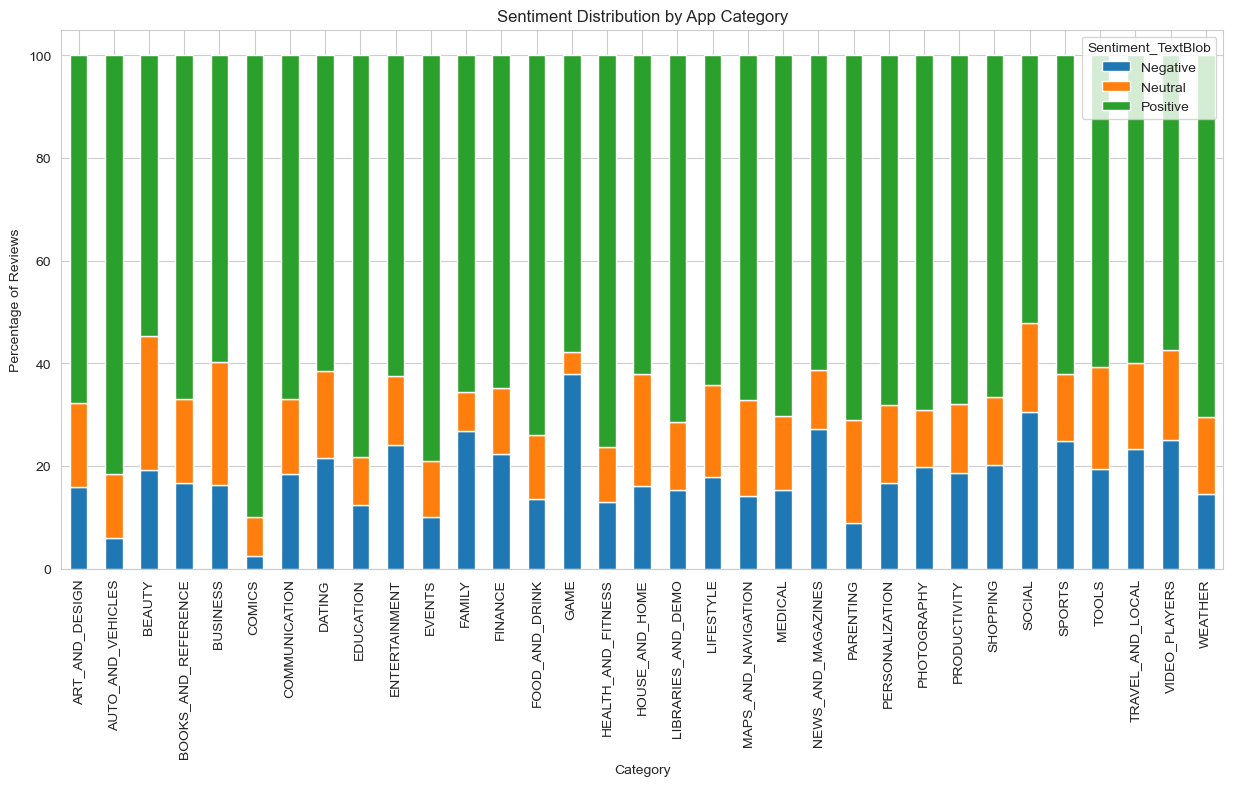

In [71]:
sentiment_category.plot(
    kind="bar",
    stacked=True,
    figsize=(15,7)
)

plt.title("Sentiment Distribution by App Category")
plt.xlabel("Category")
plt.ylabel("Percentage of Reviews")
plt.xticks(rotation=90)

plt.show()

In [72]:
sentiment_category.sort_values(
    "Positive",
    ascending=False
).head(10)

Sentiment_TextBlob,Negative,Neutral,Positive
Category,,,
COMICS,2.500000,7.500000,90.000000
AUTO_AND_VEHICLES,5.882353,12.456747,81.660900
EVENTS,10.126582,10.759494,79.113924
EDUCATION,12.302285,9.402460,78.295255
HEALTH_AND_FITNESS,12.956461,10.779494,76.264045
FOOD_AND_DRINK,13.528591,12.412831,74.058577
LIBRARIES_AND_DEMO,15.315315,13.213213,71.471471
PARENTING,8.846154,20.000000,71.153846
WEATHER,14.592275,15.021459,70.386266


In [73]:
sentiment_category.sort_values(
    "Negative",
    ascending=False
).head(10)

Sentiment_TextBlob,Negative,Neutral,Positive
Category,,,
GAME,37.880718,4.331210,57.788072
SOCIAL,30.484581,17.444934,52.070485
NEWS_AND_MAGAZINES,27.098675,11.487482,61.413844
FAMILY,26.710817,7.726269,65.562914
VIDEO_PLAYERS,25.075529,17.522659,57.401813
SPORTS,24.901704,13.018785,62.079511
ENTERTAINMENT,24.132948,13.367052,62.500000
TRAVEL_AND_LOCAL,23.356759,16.618437,60.024804
FINANCE,22.331155,12.854031,64.814815


## Find Apps with Strong Positive/Negative Feedback

In [74]:
positive_apps = (
    merged_df[merged_df["Sentiment_TextBlob"] == "Positive"]
    .groupby("App")
    .size()
    .sort_values(ascending=False)
)

positive_apps.head(10)

App
Helix Jump                        1254
Duolingo: Learn Languages Free    1000
Bowmasters                         845
8 Ball Pool                        728
Angry Birds Classic                620
Bubble Shooter                     600
Google Photos                      572
Candy Crush Saga                   510
Calorie Counter - MyFitnessPal     507
Clash Royale                       428
dtype: int64

In [75]:
negative_apps = (
    merged_df[merged_df["Sentiment_TextBlob"] == "Negative"]
    .groupby("App")
    .size()
    .sort_values(ascending=False)
)

negative_apps.head(10)

App
8 Ball Pool              742
Angry Birds Classic      735
Candy Crush Saga         630
Bowmasters               595
Helix Jump               348
Candy Crush Soda Saga    288
Garena Free Fire         243
Bubble Shooter           240
Clash Royale             232
Farm Heroes Saga         215
dtype: int64

## Create a Correlation Matrix

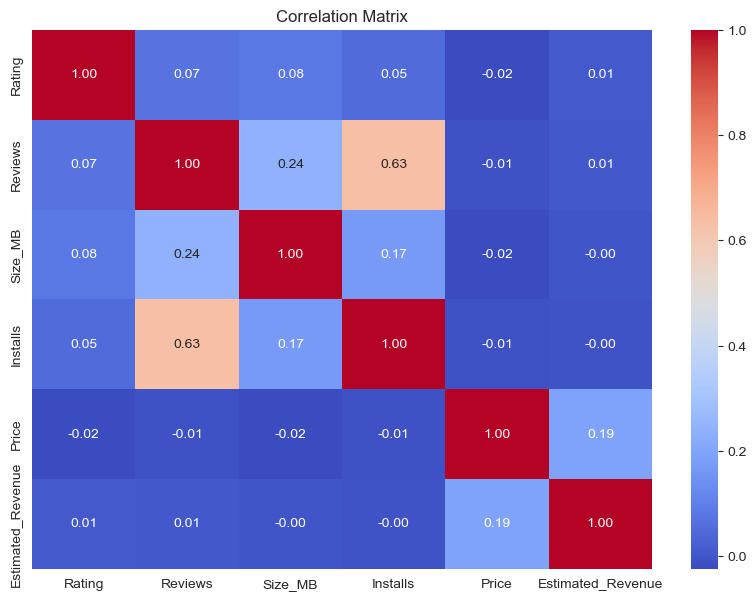

In [76]:
numeric_cols = [
    "Rating",
    "Reviews",
    "Size_MB",
    "Installs",
    "Price",
    "Estimated_Revenue"
]

corr = df[numeric_cols].corr()

plt.figure(figsize=(10,7))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.show()

## Final 3 Developer Insights

**Insight 1 — Market competition**
* The category analysis shows that some categories contain substantially more applications than others. This indicates higher competition and saturation in those segments. A new developer should therefore identify a specific niche or underserved user need rather than entering a highly crowded category with a generic application.
* **Insight 2 — Monetization**
* The Play Store ecosystem is dominated by free applications, indicating that users generally have a low barrier to downloading apps. Developers launching a new application should consider a freemium strategy, advertising, subscriptions, or in-app purchases rather than relying exclusively on an upfront paid model.
* **Insight 3 — User experience**
* Rating and sentiment analysis can reveal which categories receive stronger or weaker user feedback. A developer should prioritize app stability, usability, performance, and features associated with negative reviews before launch, while incorporating characteristics commonly associated with positive user experiences.